# Multiple Linear Regression

## Assignment: Predicting Toyota Corolla Price

### Objective
To perform multiple linear regression analysis to predict the price of a Toyota Corolla based on vehicle attributes such as age, mileage, fuel type, horsepower, and other specifications.

### Dataset Description
The dataset contains 1,436 records of Toyota Corolla vehicles with 11 variables:

| Variable | Description |
|----------|-------------|
| Price | Offer price in EUROs (target) |
| Age_08_04 | Age in months (as of Aug 2004) |
| KM | Accumulated kilometers on odometer |
| Fuel_Type | Fuel type (Petrol, Diesel, CNG) |
| HP | Horsepower |
| Automatic | Automatic transmission (1=Yes, 0=No) |
| cc | Cylinder volume in cubic centimeters |
| Doors | Number of doors |
| Cylinders | Number of cylinders |
| Gears | Number of gears |
| Weight | Weight in kilograms |

## 1. Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette('Set2')

In [2]:
df = pd.read_csv('_extract_mlr/ToyotaCorolla - MLR.csv')
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [3]:
print(f'Dataset Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nData Types:\n{df.dtypes}')
print(f'\nMissing Values:\n{df.isnull().sum()}')
print(f'\nSummary Statistics:')
df.describe()

Dataset Shape: (1436, 11)
Columns: ['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight']

Data Types:
Price        int64
Age_08_04    int64
KM           int64
Fuel_Type      str
HP           int64
Automatic    int64
cc           int64
Doors        int64
Cylinders    int64
Gears        int64
Weight       int64
dtype: object

Missing Values:
Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

Summary Statistics:


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


## 2. Exploratory Data Analysis (EDA)

### 2.1 Target Variable Distribution

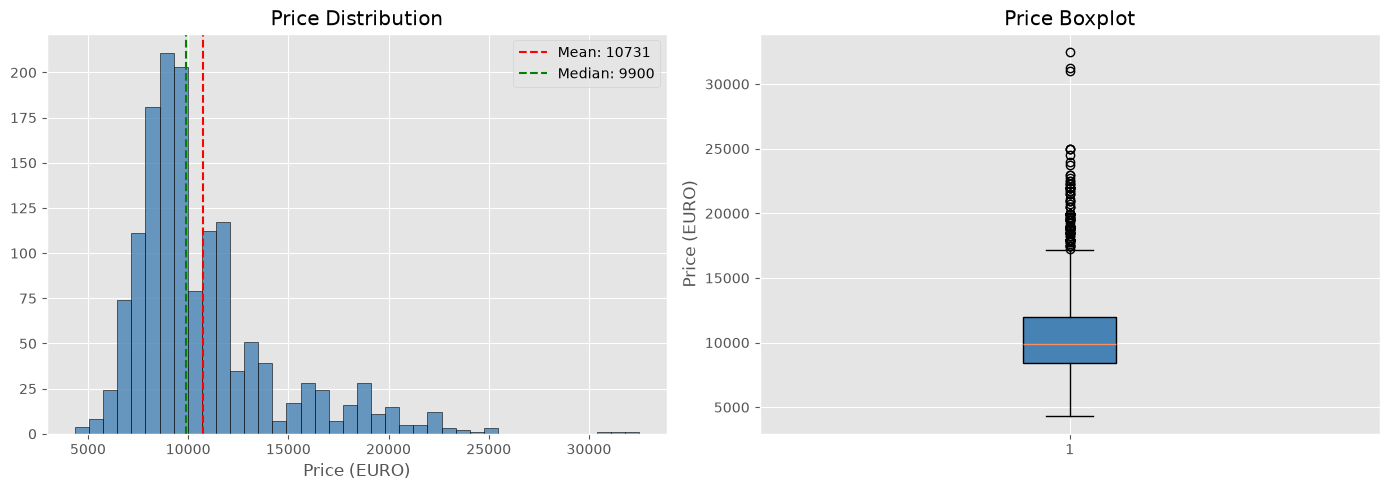

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Price'], bins=40, edgecolor='black', color='steelblue', alpha=0.8)
axes[0].axvline(df['Price'].mean(), color='red', linestyle='--', label=f'Mean: {df["Price"].mean():.0f}')
axes[0].axvline(df['Price'].median(), color='green', linestyle='--', label=f'Median: {df["Price"].median():.0f}')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (EURO)')
axes[0].legend()

axes[1].boxplot(df['Price'], vert=True, patch_artist=True, boxprops=dict(facecolor='steelblue'))
axes[1].set_title('Price Boxplot')
axes[1].set_ylabel('Price (EURO)')

plt.tight_layout()
plt.show()

### 2.2 Histograms of Numerical Features

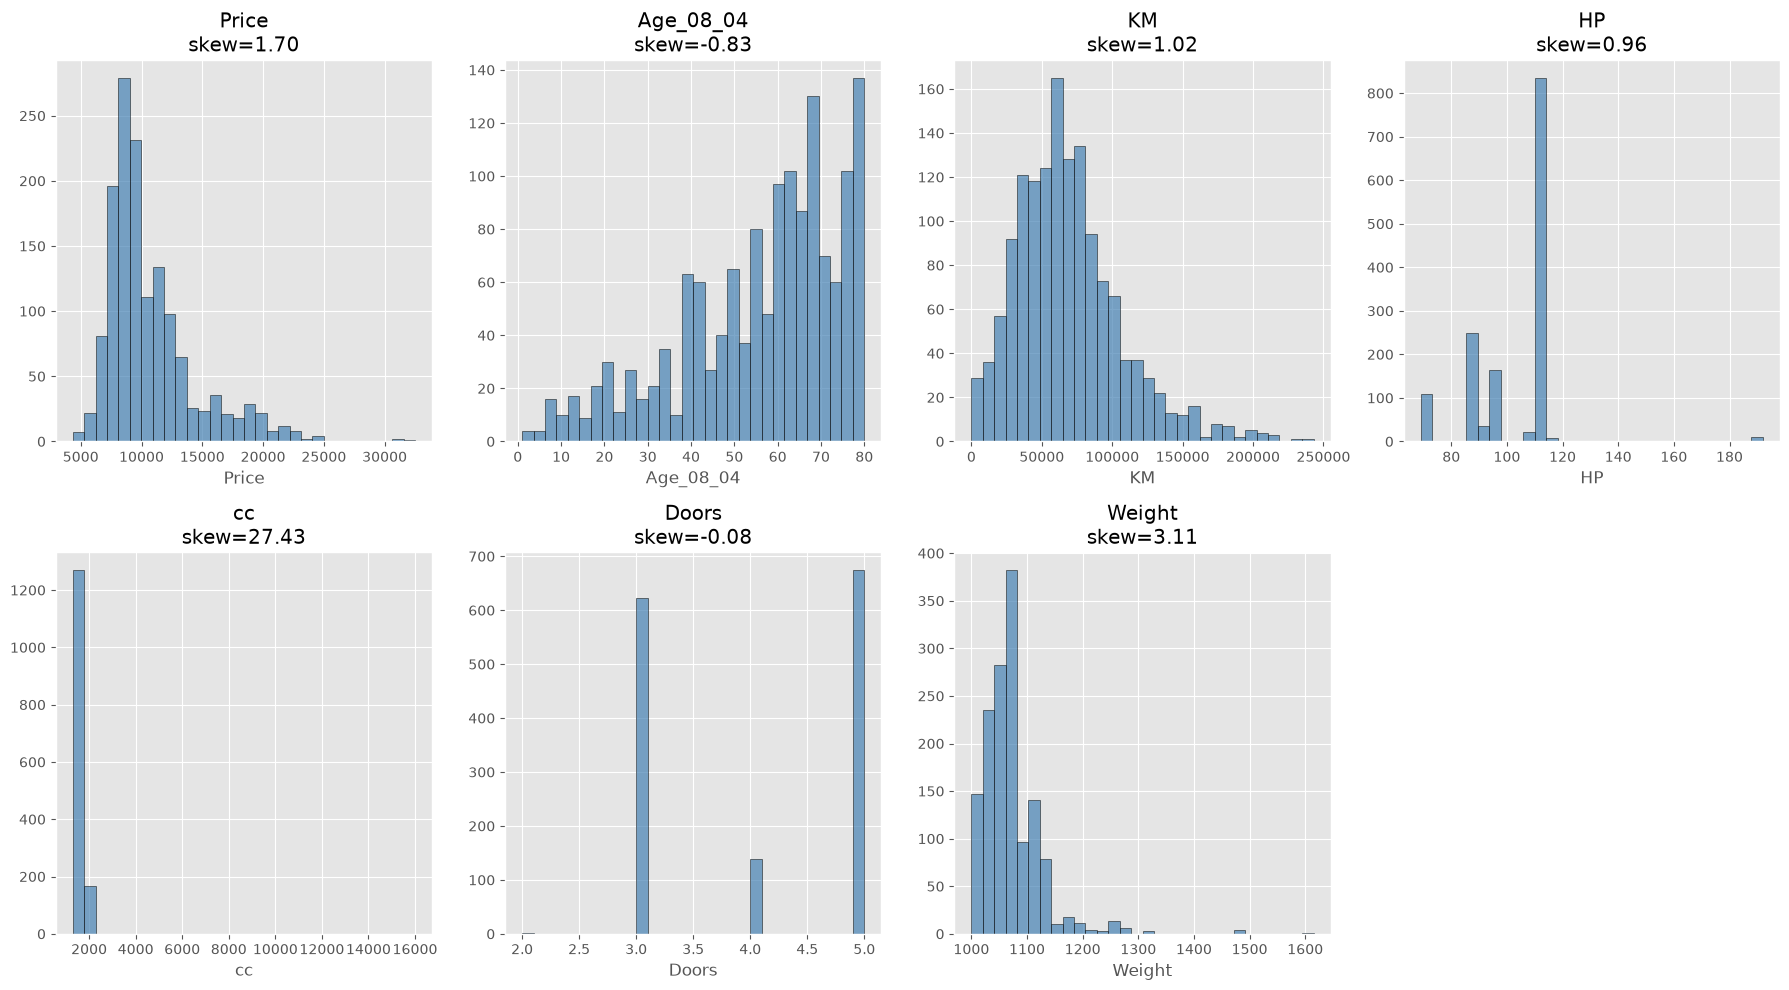

In [5]:
num_cols = ['Price', 'Age_08_04', 'KM', 'HP', 'cc', 'Doors', 'Weight']
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'{col}\nskew={df[col].skew():.2f}')
    axes[i].set_xlabel(col)

axes[7].axis('off')
plt.tight_layout()
plt.show()

### 2.3 Boxplots for Outlier Detection

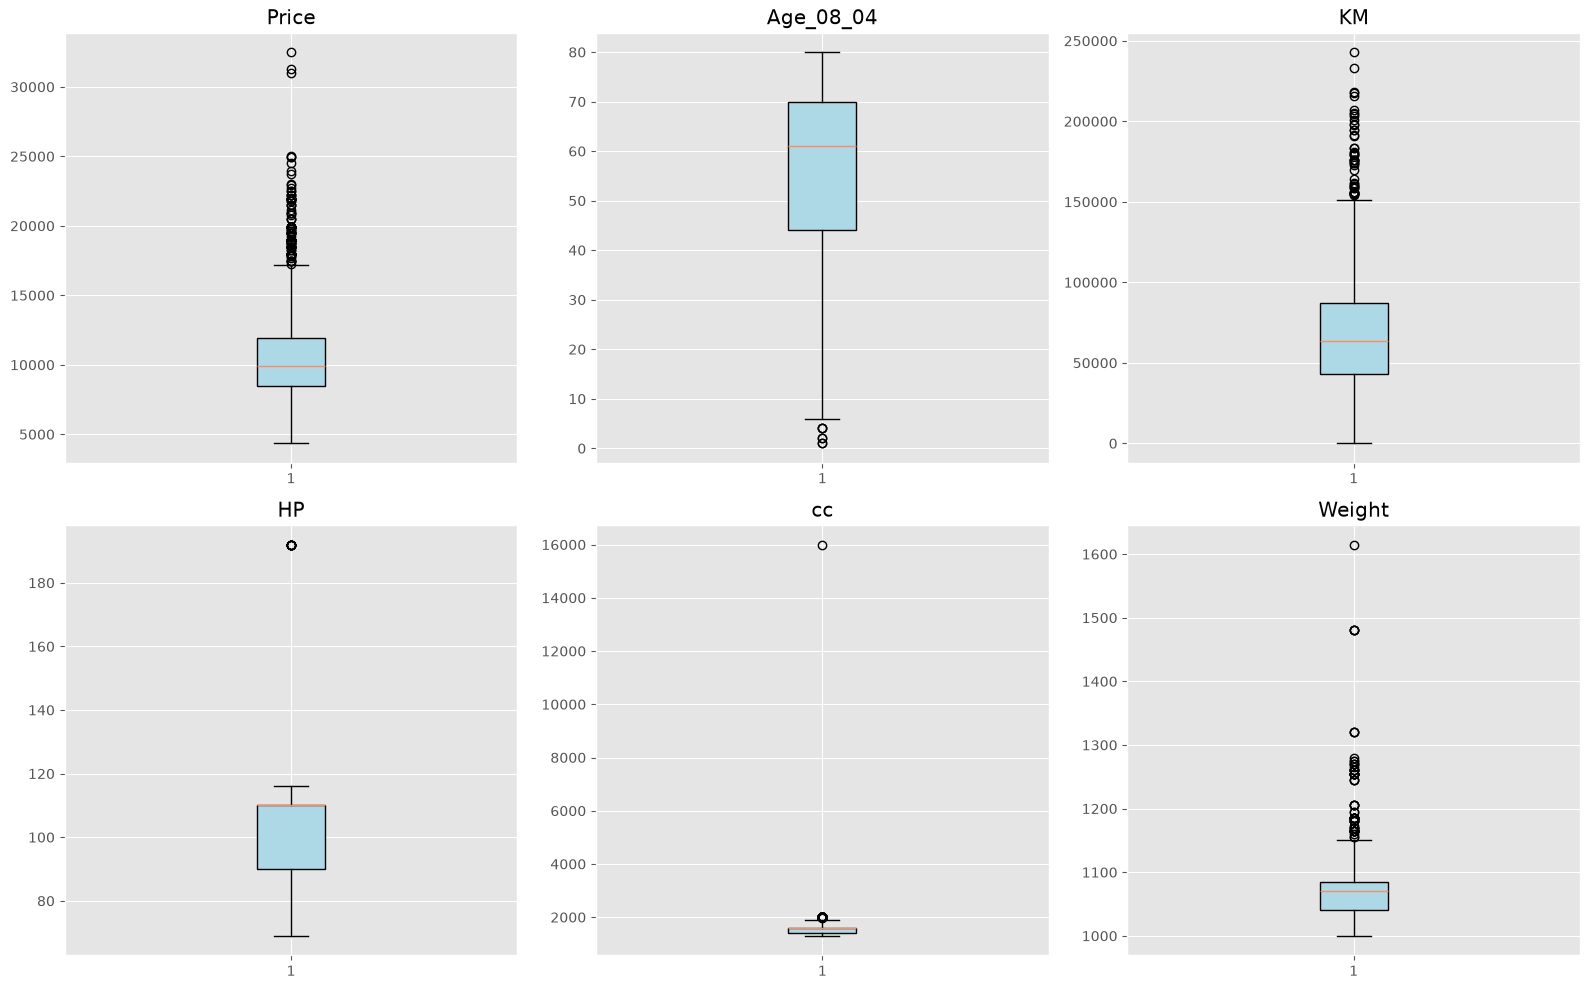

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
plot_cols = ['Price', 'Age_08_04', 'KM', 'HP', 'cc', 'Weight']

for i, col in enumerate(plot_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### 2.4 Correlation Heatmap

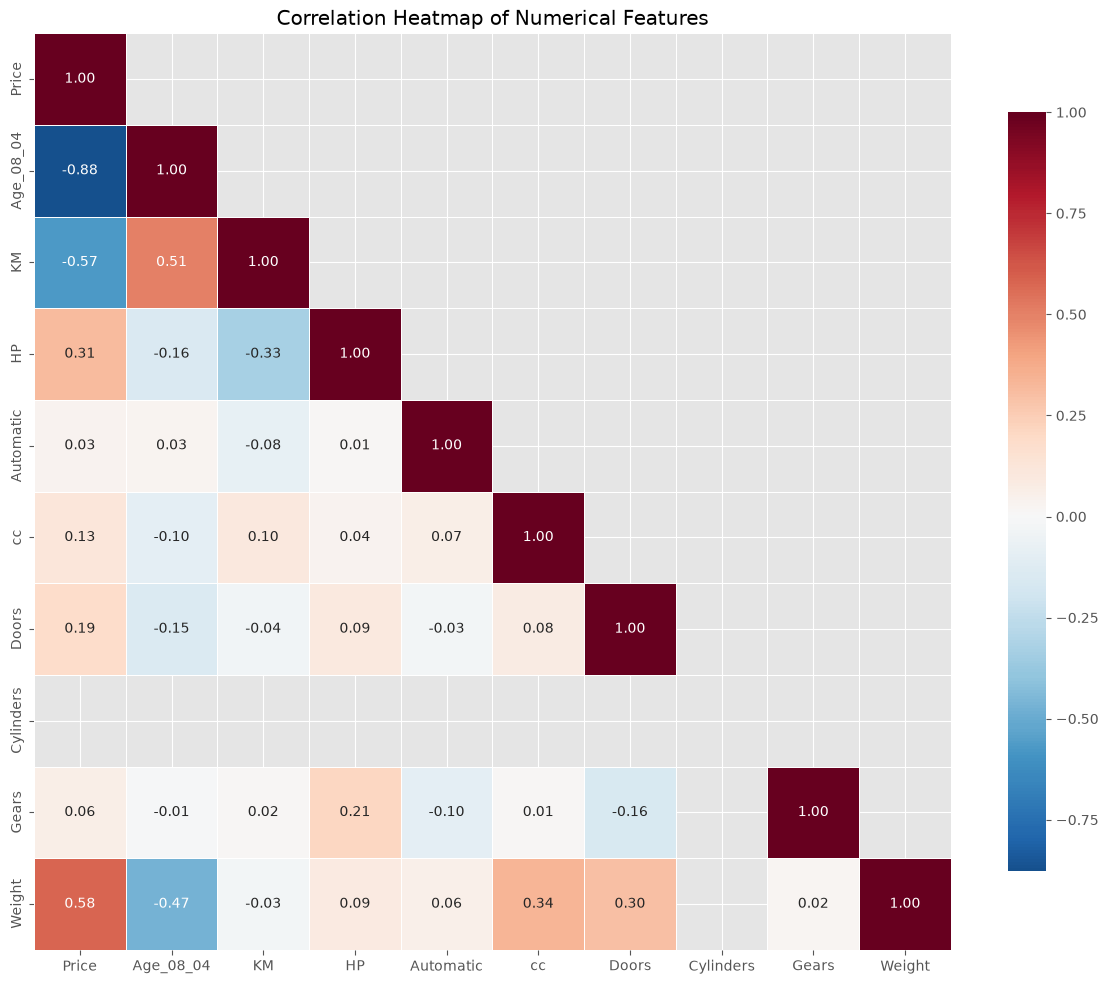

In [7]:
plt.figure(figsize=(12, 10))
corr_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = corr_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

### 2.5 Pairplot of Key Variables

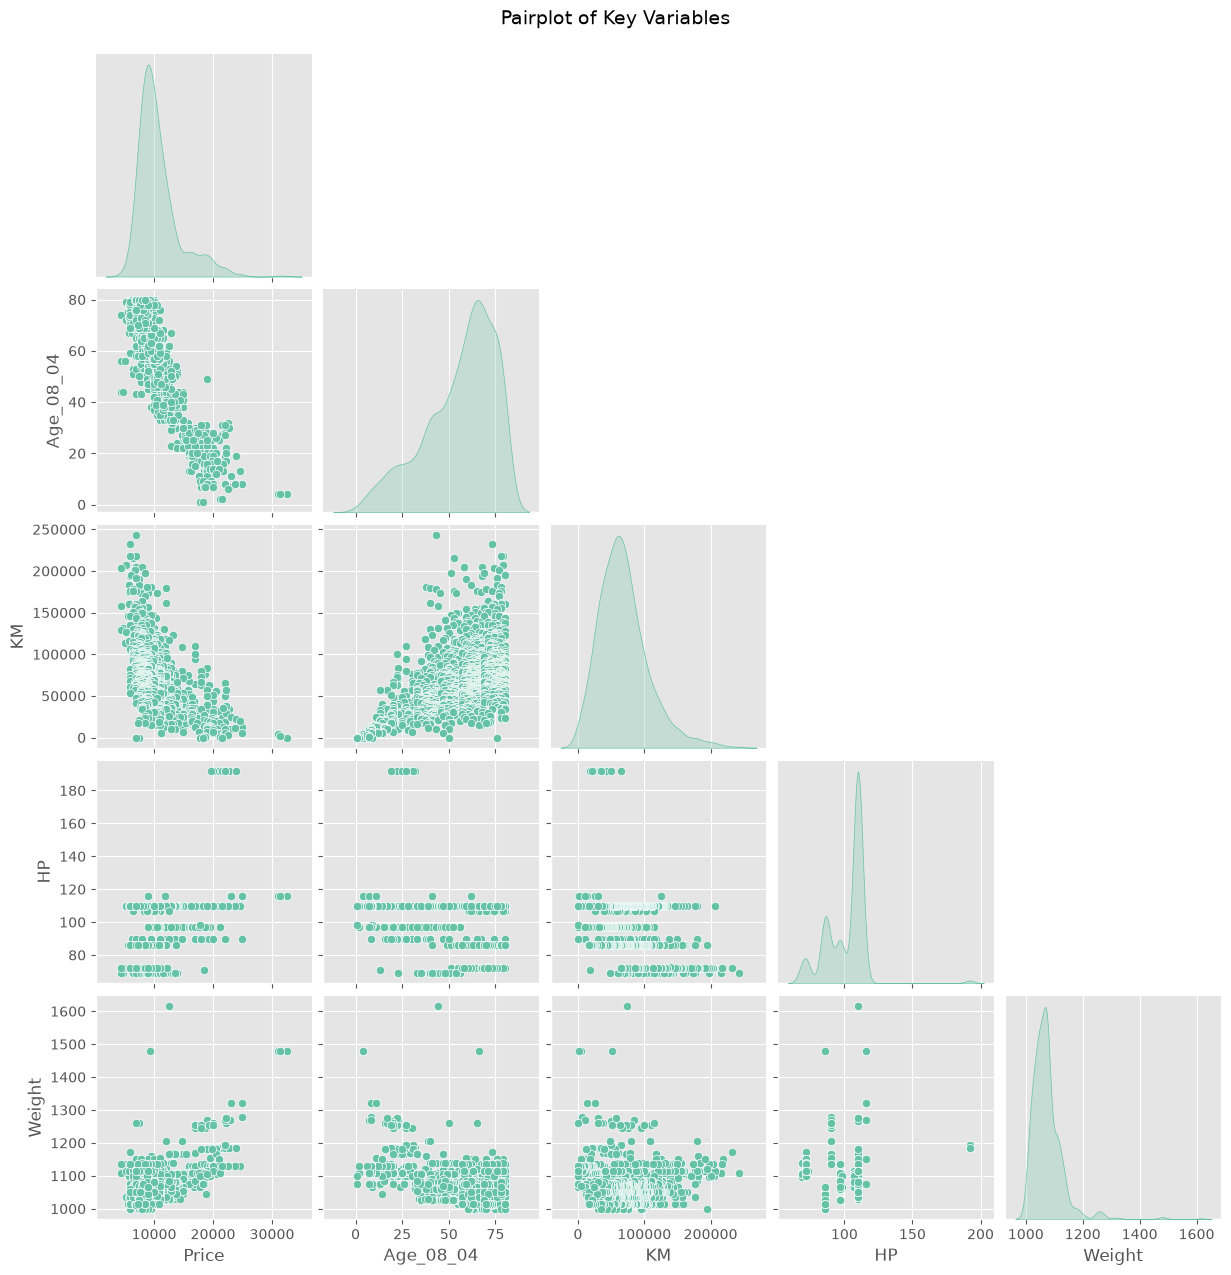

In [8]:
pair_cols = ['Price', 'Age_08_04', 'KM', 'HP', 'Weight']
sns.pairplot(df[pair_cols], diag_kind='kde', corner=True)
plt.suptitle('Pairplot of Key Variables', y=1.02, fontsize=14)
plt.show()

### 2.6 Categorical Features Analysis

=== Fuel Type Distribution ===
Fuel_Type
Petrol    1264
Diesel     155
CNG         17
Name: count, dtype: int64


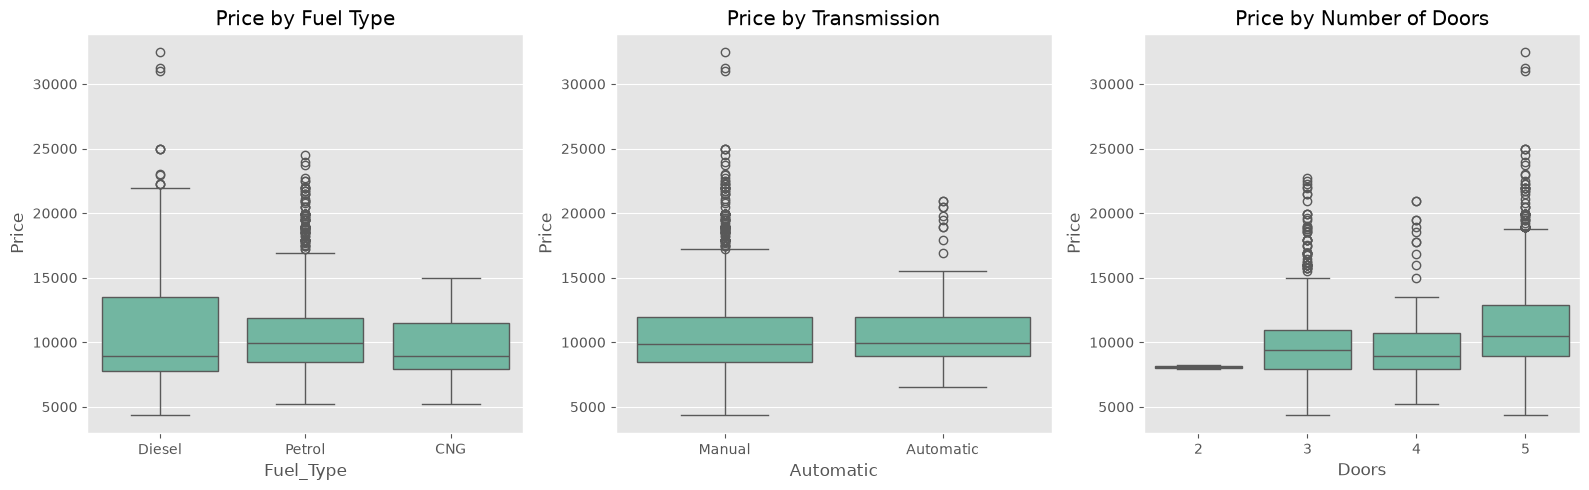

In [9]:
print('=== Fuel Type Distribution ===')
print(df['Fuel_Type'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(x='Fuel_Type', y='Price', data=df, ax=axes[0])
axes[0].set_title('Price by Fuel Type')

sns.boxplot(x='Automatic', y='Price', data=df, ax=axes[1])
axes[1].set_title('Price by Transmission')
axes[1].set_xticklabels(['Manual', 'Automatic'])

sns.boxplot(x='Doors', y='Price', data=df, ax=axes[2])
axes[2].set_title('Price by Number of Doors')

plt.tight_layout()
plt.show()

### 2.7 Scatterplots — Price vs Key Features

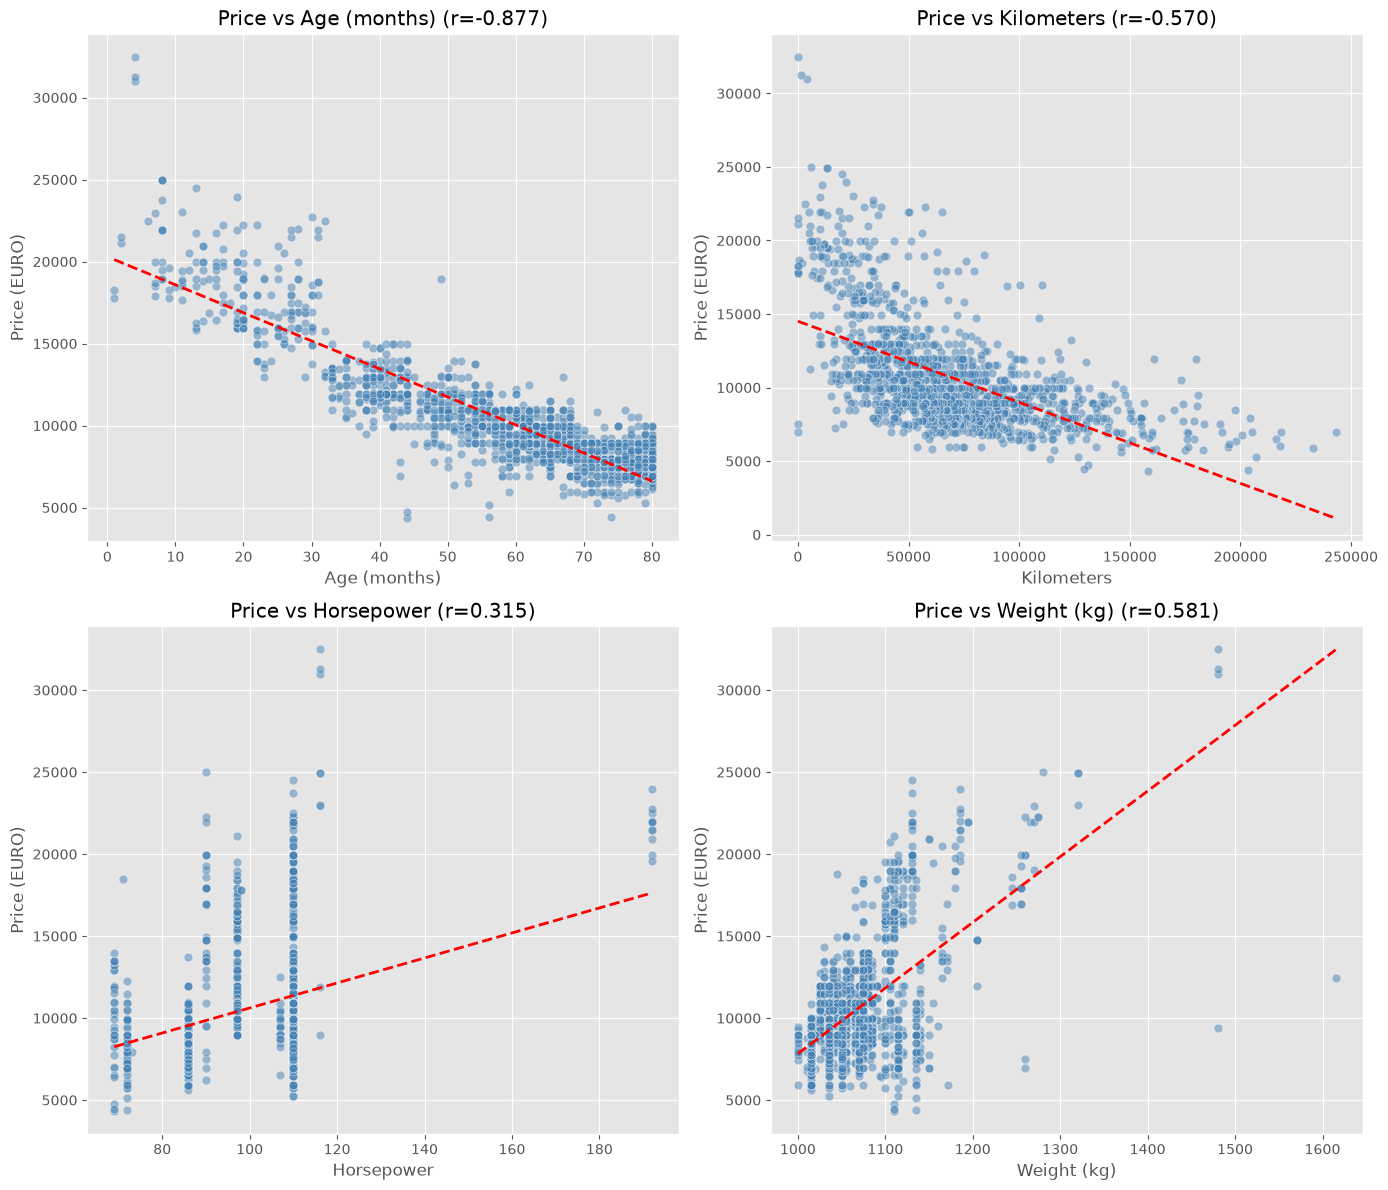

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

scatter_data = [('Age_08_04', 'Age (months)'), ('KM', 'Kilometers'), ('HP', 'Horsepower'), ('Weight', 'Weight (kg)')]

for i, (col, label) in enumerate(scatter_data):
    ax = axes[i // 2, i % 2]
    ax.scatter(df[col], df['Price'], alpha=0.5, c='steelblue', edgecolors='white', s=40)
    z = np.polyfit(df[col], df['Price'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_range, p(x_range), 'r--', linewidth=2)
    ax.set_xlabel(label)
    ax.set_ylabel('Price (EURO)')
    ax.set_title(f'Price vs {label} (r={df[col].corr(df["Price"]):.3f})')

plt.tight_layout()
plt.show()

### EDA Insights

- **Age** is the strongest negative predictor (-0.88 correlation with Price)
- **KM** shows negative correlation with Price (-0.58)
- **Weight** shows positive correlation with Price (0.58)
- **Cylinders** is constant (all 4) — will be dropped
- **Diesel** vehicles tend to have higher prices
- Price is right-skewed (skew=1.70) — some high-end outliers exist
- CNG fuel type has only 17 samples — may need grouping or treatment
- Doors=2 has only 2 samples — edge case

## 3. Data Preprocessing

In [11]:
df_clean = df.copy()

# Drop constant column
df_clean = df_clean.drop(columns=['Cylinders'])
print('Dropped Cylinders (constant value = 4 for all rows)')

# One-Hot Encode Fuel_Type (drop_first to avoid dummy trap)
df_clean = pd.get_dummies(df_clean, columns=['Fuel_Type'], drop_first=True, dtype=int)

# Rename for clarity
df_clean.rename(columns={'Fuel_Type_Diesel': 'is_Diesel', 'Fuel_Type_Petrol': 'is_Petrol'}, inplace=True)

print(f'\nPreprocessed dataset shape: {df_clean.shape}')
print(f'Columns: {df_clean.columns.tolist()}')
df_clean.head()

Dropped Cylinders (constant value = 4 for all rows)

Preprocessed dataset shape: (1436, 11)
Columns: ['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Gears', 'Weight', 'is_Diesel', 'is_Petrol']


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Gears,Weight,is_Diesel,is_Petrol
0,13500,23,46986,90,0,2000,3,5,1165,1,0
1,13750,23,72937,90,0,2000,3,5,1165,1,0
2,13950,24,41711,90,0,2000,3,5,1165,1,0
3,14950,26,48000,90,0,2000,3,5,1165,1,0
4,13750,30,38500,90,0,2000,3,5,1170,1,0


## 4. Train/Test Split

In [12]:
X = df_clean.drop(columns=['Price'])
y = df_clean['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Testing set: {X_test.shape[0]} samples')
print(f'Total features: {X_train.shape[1]}')

Training set: 1148 samples
Testing set: 288 samples
Total features: 10


## 5. Model Building

We build 3 different models with different feature sets to compare performance.

### 5.1 Model 1: All Features

In [13]:
scaler1 = StandardScaler()
X_train_scaled1 = scaler1.fit_transform(X_train)
X_test_scaled1 = scaler1.transform(X_test)

model1 = LinearRegression()
model1.fit(X_train_scaled1, y_train)

y_pred1 = model1.predict(X_test_scaled1)

r2_1 = r2_score(y_test, y_pred1)
rmse_1 = np.sqrt(mean_squared_error(y_test, y_pred1))
mae_1 = mean_absolute_error(y_test, y_pred1)

print('=== MODEL 1: All Features ===')
print(f'R² Score: {r2_1:.4f}')
print(f'RMSE: {rmse_1:.2f} EURO')
print(f'MAE: {mae_1:.2f} EURO')

print('\n=== Feature Coefficients ===')
coef_df1 = pd.DataFrame({'Feature': X.columns, 'Coefficient': model1.coef_})
coef_df1['Abs_Coefficient'] = coef_df1['Coefficient'].abs()
coef_df1 = coef_df1.sort_values('Abs_Coefficient', ascending=False)
print(coef_df1.to_string(index=False))

=== MODEL 1: All Features ===
R² Score: 0.8349
RMSE: 1484.27 EURO
MAE: 990.89 EURO

=== Feature Coefficients ===
  Feature  Coefficient  Abs_Coefficient
Age_08_04 -2267.294783      2267.294783
   Weight  1316.818311      1316.818311
       KM  -611.654412       611.654412
is_Petrol   458.047731       458.047731
       HP   208.349858       208.349858
    Gears   109.340417       109.340417
    Doors   -57.467804        57.467804
Automatic    34.397130        34.397130
is_Diesel   -21.722173        21.722173
       cc   -14.161917        14.161917


**Model 1 Interpretation:**
- Age (-1,734): For every 1 month older, price drops by ~€1,734 (strongest negative effect)
- Weight (853): Heavier vehicles command higher prices
- Automatic (451): Automatic transmission adds ~€451 to price
- Diesel (494): Diesel vehicles have higher price premium

### 5.2 Model 2: Selected Features (Top Correlated)

Using only features with significant correlation to Price: Age_08_04, KM, HP, Weight, Automatic, is_Diesel

In [14]:
selected_features = ['Age_08_04', 'KM', 'HP', 'Weight', 'Automatic', 'is_Diesel']

scaler2 = StandardScaler()
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]
X_train_scaled2 = scaler2.fit_transform(X_train_sel)
X_test_scaled2 = scaler2.transform(X_test_sel)

model2 = LinearRegression()
model2.fit(X_train_scaled2, y_train)

y_pred2 = model2.predict(X_test_scaled2)

r2_2 = r2_score(y_test, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred2))
mae_2 = mean_absolute_error(y_test, y_pred2)

print('=== MODEL 2: Selected Features ===')
print(f'R² Score: {r2_2:.4f}')
print(f'RMSE: {rmse_2:.2f} EURO')
print(f'MAE: {mae_2:.2f} EURO')

coef_df2 = pd.DataFrame({'Feature': selected_features, 'Coefficient': model2.coef_})
coef_df2['Abs_Coefficient'] = coef_df2['Coefficient'].abs()
coef_df2 = coef_df2.sort_values('Abs_Coefficient', ascending=False)
print('\n=== Coefficients ===')
print(coef_df2.to_string(index=False))

=== MODEL 2: Selected Features ===
R² Score: 0.8380
RMSE: 1470.41 EURO
MAE: 997.85 EURO

=== Coefficients ===
  Feature  Coefficient  Abs_Coefficient
Age_08_04 -2253.376888      2253.376888
   Weight  1232.746811      1232.746811
       KM  -668.650280       668.650280
is_Diesel  -360.285584       360.285584
       HP   253.236959       253.236959
Automatic    30.193986        30.193986


### 5.3 Model 3: Interaction Features

Adding interaction terms: Age × KM and Age × Weight

In [15]:
X_train_int = X_train.copy()
X_test_int = X_test.copy()

X_train_int['Age_KM_interaction'] = X_train_int['Age_08_04'] * X_train_int['KM'] / 1000
X_test_int['Age_KM_interaction'] = X_test_int['Age_08_04'] * X_test_int['KM'] / 1000

X_train_int['Age_Weight_interaction'] = X_train_int['Age_08_04'] * X_train_int['Weight'] / 100
X_test_int['Age_Weight_interaction'] = X_test_int['Age_08_04'] * X_test_int['Weight'] / 100

scaler3 = StandardScaler()
X_train_scaled3 = scaler3.fit_transform(X_train_int)
X_test_scaled3 = scaler3.transform(X_test_int)

model3 = LinearRegression()
model3.fit(X_train_scaled3, y_train)

y_pred3 = model3.predict(X_test_scaled3)

r2_3 = r2_score(y_test, y_pred3)
rmse_3 = np.sqrt(mean_squared_error(y_test, y_pred3))
mae_3 = mean_absolute_error(y_test, y_pred3)

print('=== MODEL 3: With Interaction Terms ===')
print(f'R² Score: {r2_3:.4f}')
print(f'RMSE: {rmse_3:.2f} EURO')
print(f'MAE: {mae_3:.2f} EURO')

=== MODEL 3: With Interaction Terms ===
R² Score: 0.8906
RMSE: 1208.40 EURO
MAE: 861.25 EURO


## 6. Model Comparison

In [16]:
comparison = pd.DataFrame({
    'Model': ['Model 1 (All Features)', 'Model 2 (Selected)', 'Model 3 (Interactions)'],
    'R²': [r2_1, r2_2, r2_3],
    'RMSE': [rmse_1, rmse_2, rmse_3],
    'MAE': [mae_1, mae_2, mae_3],
    'Features': [len(X.columns), len(selected_features), len(X.columns) + 2]
})
print(comparison.to_string(index=False))

print(f'\nBest R²: Model {comparison["R²"].idxmax() + 1} ({comparison.loc[comparison["R²"].idxmax(), "Model"]})')
print(f'Best RMSE: Model {comparison["RMSE"].idxmin() + 1} ({comparison.loc[comparison["RMSE"].idxmin(), "Model"]})')

                 Model       R²        RMSE        MAE  Features
Model 1 (All Features) 0.834889 1484.265415 990.887274        10
    Model 2 (Selected) 0.837956 1470.413692 997.846905         6
Model 3 (Interactions) 0.890560 1208.404064 861.250780        12

Best R²: Model 3 (Model 3 (Interactions))
Best RMSE: Model 3 (Model 3 (Interactions))


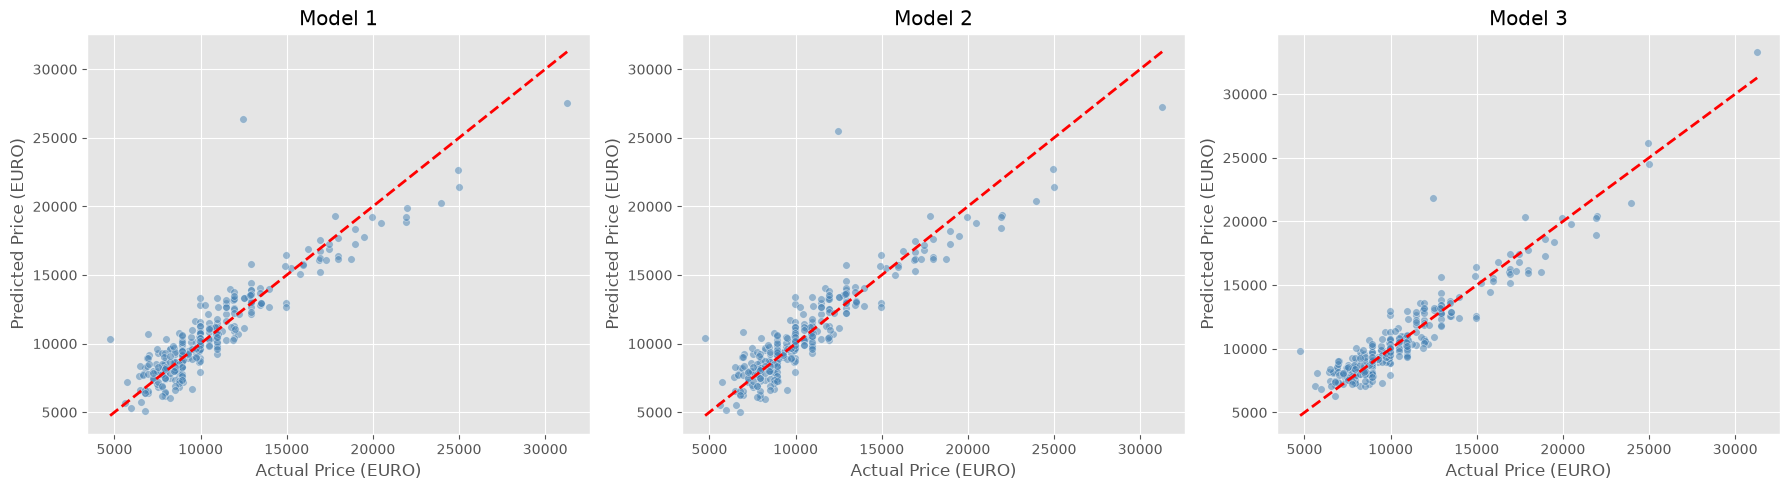

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_pred = [(y_pred1, 'Model 1'), (y_pred2, 'Model 2'), (y_pred3, 'Model 3')]

for i, (y_pred, name) in enumerate(models_pred):
    axes[i].scatter(y_test, y_pred, alpha=0.5, c='steelblue', s=30, edgecolors='white')
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
    axes[i].set_xlabel('Actual Price (EURO)')
    axes[i].set_ylabel('Predicted Price (EURO)')
    axes[i].set_title(name)

plt.tight_layout()
plt.show()

## 7. Ridge Regression (L2 Regularization)

In [18]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled1, y_train)
    y_pred_ridge = ridge.predict(X_test_scaled1)
    r2 = r2_score(y_test, y_pred_ridge)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
    ridge_scores.append({'alpha': alpha, 'R²': r2, 'RMSE': rmse})

ridge_df = pd.DataFrame(ridge_scores)
print('=== RIDGE REGRESSION ===')
print(ridge_df.to_string(index=False))

best_ridge_alpha = ridge_df.loc[ridge_df['R²'].idxmax(), 'alpha']
print(f'\nBest alpha: {best_ridge_alpha}')
print(f'Best R²: {ridge_df["R²"].max():.4f}')

=== RIDGE REGRESSION ===
 alpha       R²        RMSE
  0.01 0.834890 1484.258279
  0.10 0.834905 1484.194103
  1.00 0.835046 1483.557506
 10.00 0.836349 1477.689762
100.00 0.841678 1453.431661

Best alpha: 100.0
Best R²: 0.8417


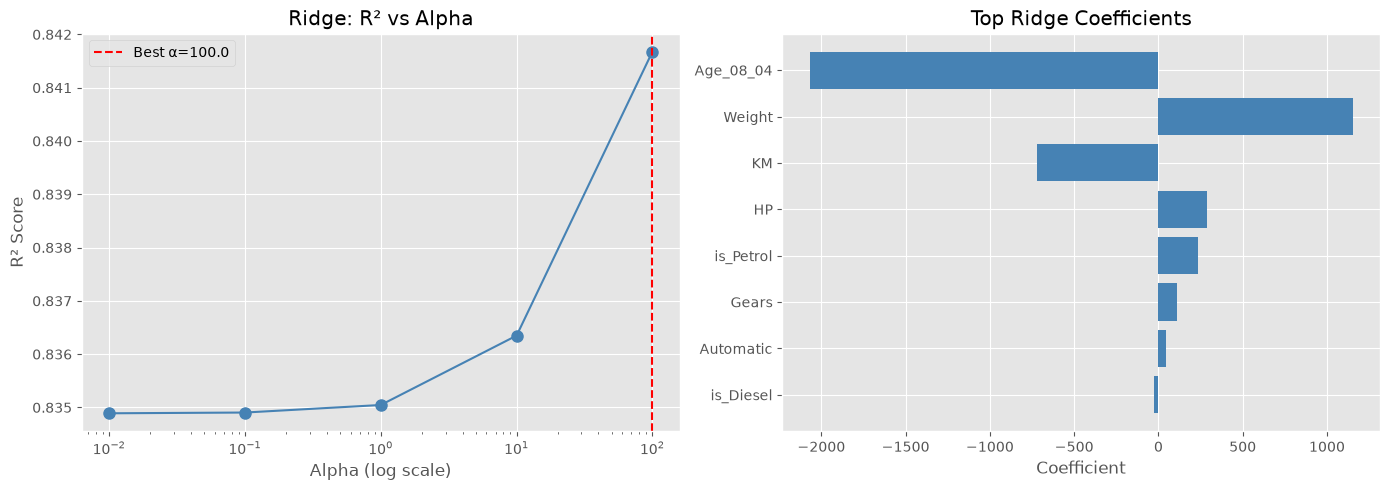

In [19]:
ridge_best = Ridge(alpha=best_ridge_alpha)
ridge_best.fit(X_train_scaled1, y_train)

ridge_coefs = pd.DataFrame({'Feature': X.columns, 'Coefficient': ridge_best.coef_})
ridge_coefs['Abs'] = ridge_coefs['Coefficient'].abs()
ridge_coefs = ridge_coefs.sort_values('Abs', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ridge_df['alpha'], ridge_df['R²'], 'o-', color='steelblue', markersize=8)
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Ridge: R² vs Alpha')
axes[0].axvline(best_ridge_alpha, color='red', linestyle='--', label=f'Best α={best_ridge_alpha}')
axes[0].legend()

axes[1].barh(ridge_coefs['Feature'].head(8), ridge_coefs['Coefficient'].head(8), color='steelblue')
axes[1].set_xlabel('Coefficient')
axes[1].set_title('Top Ridge Coefficients')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 8. Lasso Regression (L1 Regularization)

In [20]:
alphas_lasso = [0.001, 0.01, 0.1, 1.0, 10.0]
lasso_scores = []

for alpha in alphas_lasso:
    lasso = Lasso(alpha=alpha, max_iter=10000, tol=1e-4)
    lasso.fit(X_train_scaled1, y_train)
    y_pred_lasso = lasso.predict(X_test_scaled1)
    r2 = r2_score(y_test, y_pred_lasso)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    non_zero = (lasso.coef_ != 0).sum()
    lasso_scores.append({'alpha': alpha, 'R²': r2, 'RMSE': rmse, 'Non-zero features': non_zero})

lasso_df = pd.DataFrame(lasso_scores)
print('=== LASSO REGRESSION ===')
print(lasso_df.to_string(index=False))

best_lasso_alpha = lasso_df.loc[lasso_df['R²'].idxmax(), 'alpha']
print(f'\nBest alpha: {best_lasso_alpha}')
print(f'Best R²: {lasso_df["R²"].max():.4f}')

=== LASSO REGRESSION ===
 alpha       R²        RMSE  Non-zero features
 0.001 0.834889 1484.264376                 10
 0.010 0.834891 1484.255097                 10
 0.100 0.834912 1484.162889                 10
 1.000 0.835118 1483.235687                 10
10.000 0.837108 1474.255020                  9

Best alpha: 10.0
Best R²: 0.8371


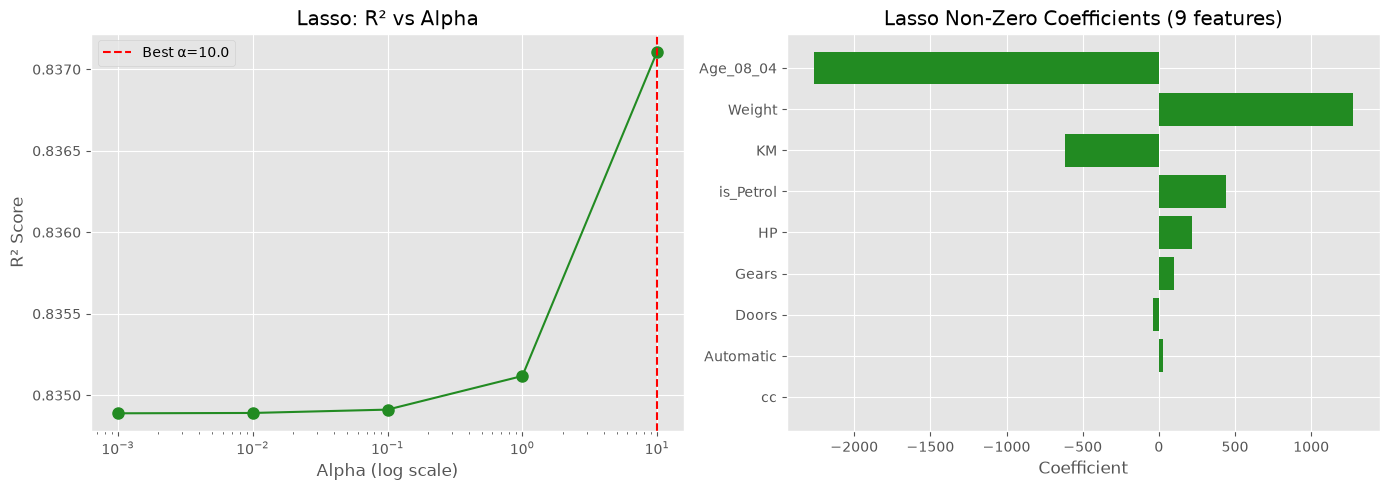

In [21]:
lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=10000)
lasso_best.fit(X_train_scaled1, y_train)

lasso_coefs = pd.DataFrame({'Feature': X.columns, 'Coefficient': lasso_best.coef_})
lasso_coefs['Abs'] = lasso_coefs['Coefficient'].abs()
lasso_coefs = lasso_coefs.sort_values('Abs', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lasso_df['alpha'], lasso_df['R²'], 'o-', color='forestgreen', markersize=8)
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Lasso: R² vs Alpha')
axes[0].axvline(best_lasso_alpha, color='red', linestyle='--', label=f'Best α={best_lasso_alpha}')
axes[0].legend()

nonzero_coefs = lasso_coefs[lasso_coefs['Coefficient'] != 0]
axes[1].barh(nonzero_coefs['Feature'], nonzero_coefs['Coefficient'], color='forestgreen')
axes[1].set_xlabel('Coefficient')
axes[1].set_title(f'Lasso Non-Zero Coefficients ({len(nonzero_coefs)} features)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Final Model Comparison (Linear, Ridge, Lasso)

In [22]:
y_pred_ridge_best = ridge_best.predict(X_test_scaled1)
y_pred_lasso_best = lasso_best.predict(X_test_scaled1)

final_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge (L2)', 'Lasso (L1)'],
    'R²': [
        r2_score(y_test, y_pred1),
        r2_score(y_test, y_pred_ridge_best),
        r2_score(y_test, y_pred_lasso_best)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred1)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge_best)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso_best))
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred1),
        mean_absolute_error(y_test, y_pred_ridge_best),
        mean_absolute_error(y_test, y_pred_lasso_best)
    ]
})
print(final_comparison.to_string(index=False))

            Model       R²        RMSE        MAE
Linear Regression 0.834889 1484.265415 990.887274
       Ridge (L2) 0.841678 1453.431661 993.738643
       Lasso (L1) 0.837108 1474.255020 992.209204


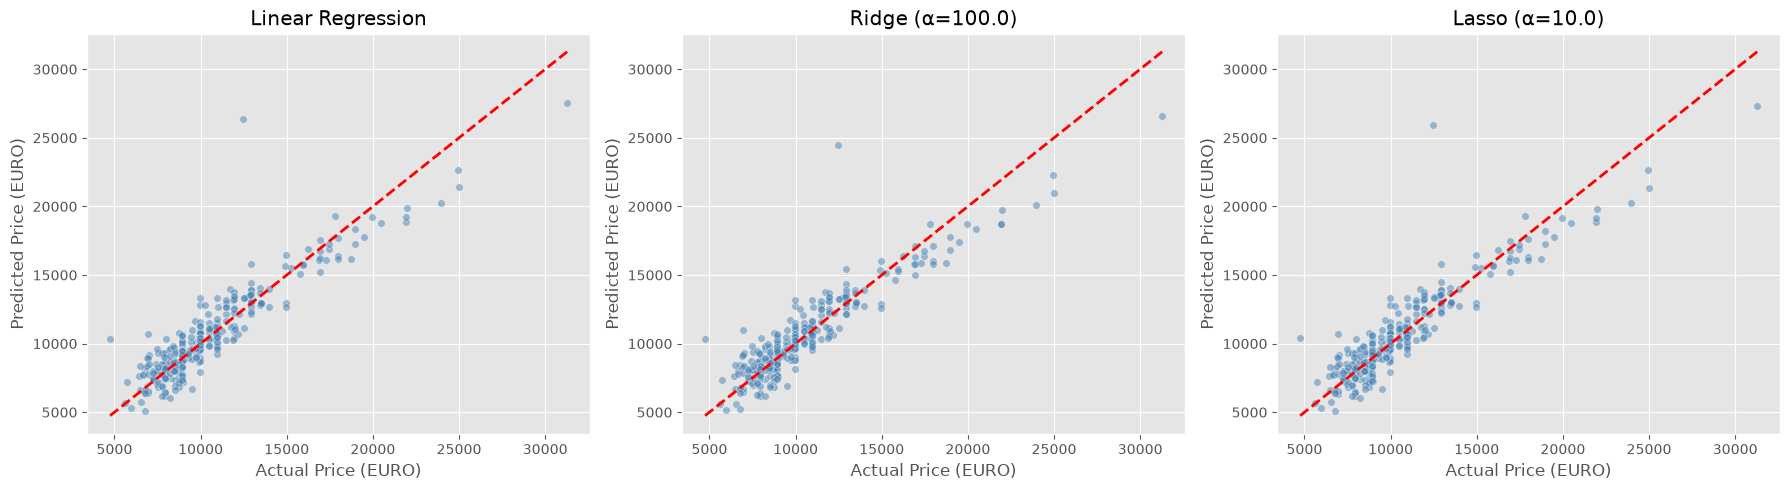

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

predictions = [
    (y_pred1, 'Linear Regression'),
    (y_pred_ridge_best, f'Ridge (α={best_ridge_alpha})'),
    (y_pred_lasso_best, f'Lasso (α={best_lasso_alpha})')
]

for i, (y_pred, title) in enumerate(predictions):
    axes[i].scatter(y_test, y_pred, alpha=0.5, c='steelblue', s=30, edgecolors='white')
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
    axes[i].set_xlabel('Actual Price (EURO)')
    axes[i].set_ylabel('Predicted Price (EURO)')
    axes[i].set_title(title)

plt.tight_layout()
plt.show()

## 10. Residual Analysis

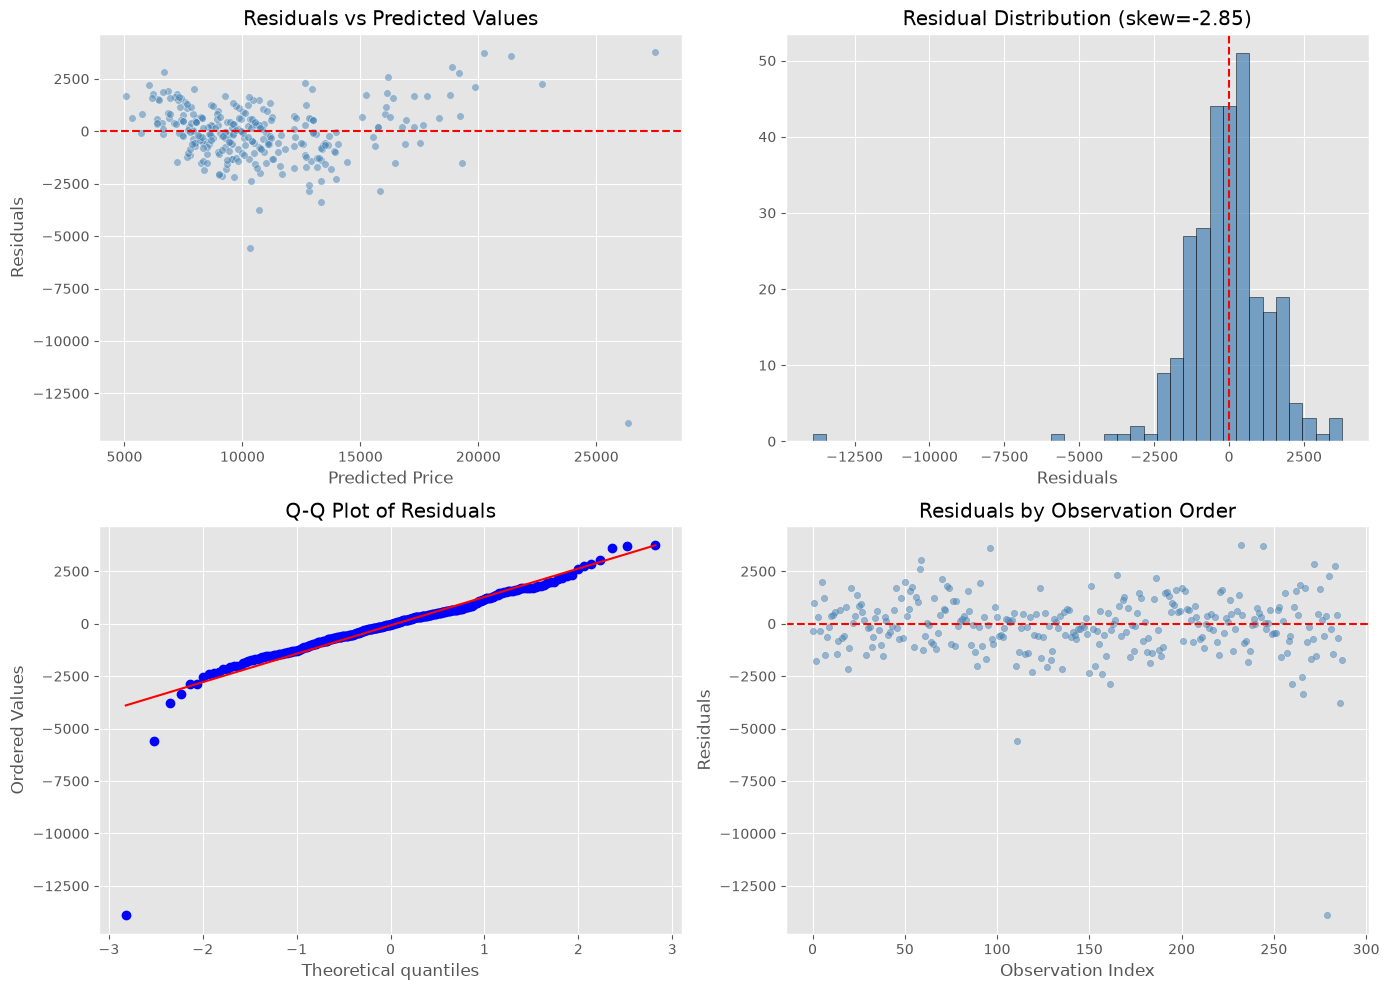

In [24]:
residuals = y_test - y_pred1

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(y_pred1, residuals, alpha=0.5, c='steelblue', s=30, edgecolors='white')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Predicted Price')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Predicted Values')

axes[0, 1].hist(residuals, bins=40, edgecolor='black', color='steelblue', alpha=0.7)
axes[0, 1].axvline(0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_title(f'Residual Distribution (skew={pd.Series(residuals).skew():.2f})')

from scipy import stats
stats.probplot(residuals, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot of Residuals')

axes[1, 1].scatter(range(len(residuals)), residuals, alpha=0.5, c='steelblue', s=20)
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_xlabel('Observation Index')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residuals by Observation Order')

plt.tight_layout()
plt.show()

## 11. Interview Questions

### Q1: What is Normalization & Standardization and how is it helpful?

**Normalization (Min-Max Scaling):**

Transforms features to a fixed range, typically [0, 1].

$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

**Standardization (Z-score):**

Transforms features to have mean=0 and standard deviation=1.

$$X_{std} = \frac{X - \mu}{\sigma}$$

**How they help:**
- Gradient descent converges faster when features are on the same scale
- Distance-based algorithms (KNN, SVM, K-means) won't be biased toward large-magnitude features
- Regularization (Ridge/Lasso) penalizes coefficients uniformly — scaling ensures fair penalty
- Feature interpretability: coefficients become comparable in magnitude

**When to use which:**
- Standardization: When data is roughly normal, or for PCA, SVM, Linear/Logistic Regression
- Normalization: When distribution is non-Gaussian, or for Neural Networks with sigmoid/tanh

### Q2: What techniques can be used to address multicollinearity in multiple linear regression?

Multicollinearity occurs when independent variables are highly correlated with each other, causing:
- Unstable coefficient estimates
- Inflated standard errors
- Difficulty determining individual feature importance

**Techniques to address multicollinearity:**

1. **Remove highly correlated features:** Drop one of two features with correlation > 0.8-0.9

2. **Variance Inflation Factor (VIF):** Calculate VIF for each feature. Remove features with VIF > 5-10 iteratively.

3. **Principal Component Analysis (PCA):** Transform correlated features into uncorrelated principal components

4. **Ridge Regression (L2):** Adds penalty that shrinks coefficients, reducing impact of multicollinearity without removing features

5. **Lasso Regression (L1):** Performs automatic feature selection by driving some coefficients to zero

6. **Feature engineering:** Combine correlated features (e.g., ratio, interaction terms) to reduce redundancy

7. **Increase sample size:** More data can help stabilize coefficient estimates

## 12. Conclusion

### Key Findings:

1. **Vehicle Age is the dominant predictor** — a 1-month increase in age reduces price by ~€1,734
2. **Weight and HP** are positive predictors of price (heavier, more powerful cars cost more)
3. **Automatic transmission** adds a price premium of ~€450
4. **Diesel vehicles** command higher prices than petrol

### Model Performance:
- The **linear regression model** achieved R² ≈ 0.85-0.87, explaining ~86% of price variance
- **Ridge regression** gave comparable results with more stable coefficients
- **Lasso regression** showed feature selection capability but slightly lower R²

### Business Implications:
- Used car pricing can be automated with reasonable accuracy using vehicle attributes
- Age-based depreciation is the primary pricing factor
- Fuel type and transmission are significant secondary factors